<a href="https://colab.research.google.com/github/smdarshad000-lab/data-science-concepts/blob/main/Exp4_Arshad_PR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experiment-4  
Submitted By:- SMD Arshad
###Aim: To implement K-Means clustering for unsupervised pattern recognition, analyze cluster formation using Euclidean distance, determine the optimal number of clusters using the Elbow method, and explore advanced real-world applications.    
###Objectives:  
1.	Understand the concept of unsupervised learning.  
2.	Explain centroid-based clustering.  
3.	Derive and interpret the K-Means objective function.  
4.	Implement K-Means algorithm using Python.  
5.	Compute Within-Cluster Sum of Squares (WCSS).  
6.	Apply the Elbow method to determine optimal K.  
7.	Visualize clustering in feature space.  
8.	Apply clustering to image segmentation (advanced task).  
9.	Interpret clustering results from a pattern recognition perspective    
###Implementation steps:  
1. Implement K-means clustering with different k values (2, 3, 5, 7)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import mnist

In [ ]:
(X_train, y_train), _ = mnist.load_data()

# I used subset of MNIST as original dataset has 70,000 images which is not efficient right now
X = X_train[:2000]
y = y_train[:2000]
X_flat = X.reshape(2000, -1)
X_flat = X_flat / 255.0
print("Dataset shape:", X_flat.shape)


Dataset shape: (2000, 784)


In [ ]:
k_values = range(1, 11)
wcss = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_flat)
    wcss.append(kmeans.inertia_)

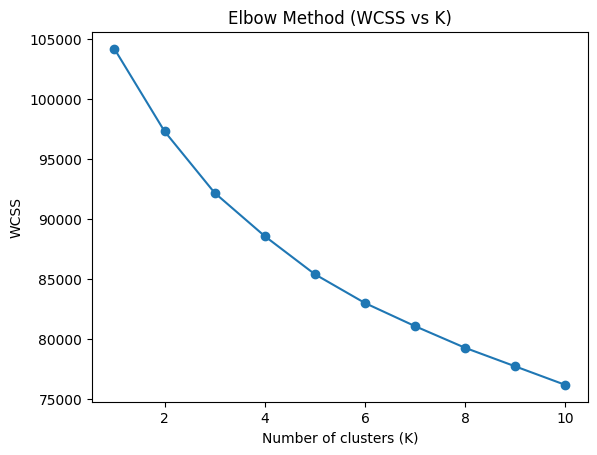

In [ ]:
plt.figure()
plt.plot(k_values, wcss, marker='o')
plt.title("Elbow Method (WCSS vs K)")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [ ]:
k_list = [2, 3, 5, 7]
models = {}

for k in k_list:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_flat)
    models[k] = (model, labels)

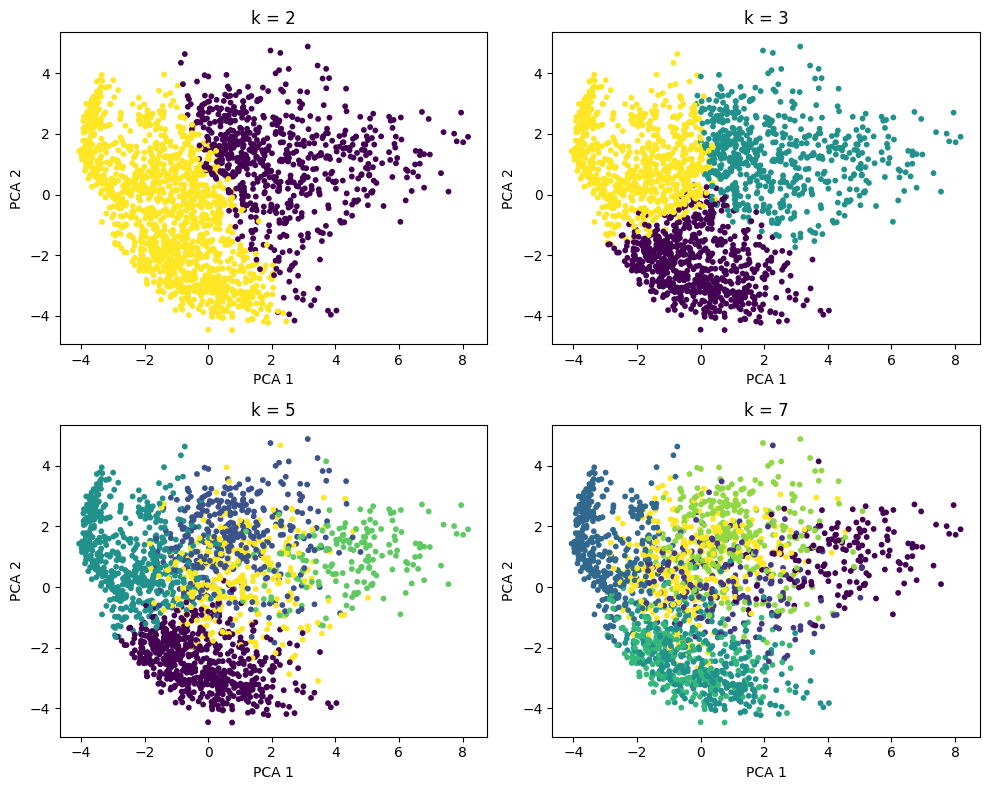

In [ ]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_flat)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for i, k in enumerate(k_list):
    _, labels = models[k]

    axes[i].scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels, s=10)
    axes[i].set_title(f"k = {k}")
    axes[i].set_xlabel("PCA 1")
    axes[i].set_ylabel("PCA 2")

plt.tight_layout()
plt.show()

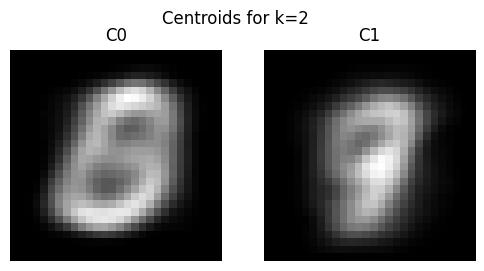

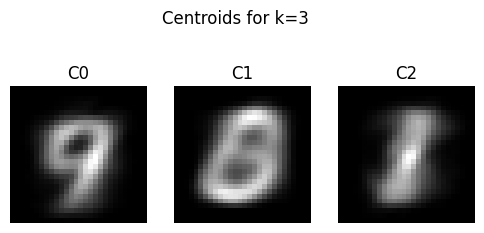

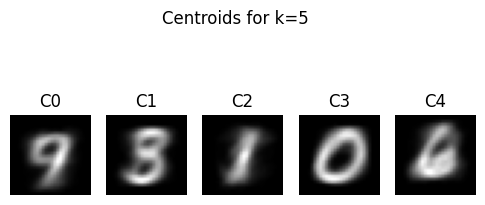

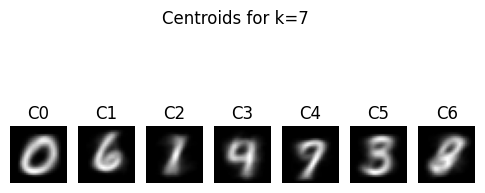

In [ ]:
def show_centroids(k, model):
    centroids = model.cluster_centers_

    plt.figure(figsize=(6, 3))
    for i in range(k):
        plt.subplot(1, k, i+1)
        plt.imshow(centroids[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
        plt.title(f"C{i}")
    plt.suptitle(f"Centroids for k={k}")
    plt.show()

for k in k_list:
    model, _ = models[k]
    show_centroids(k, model)

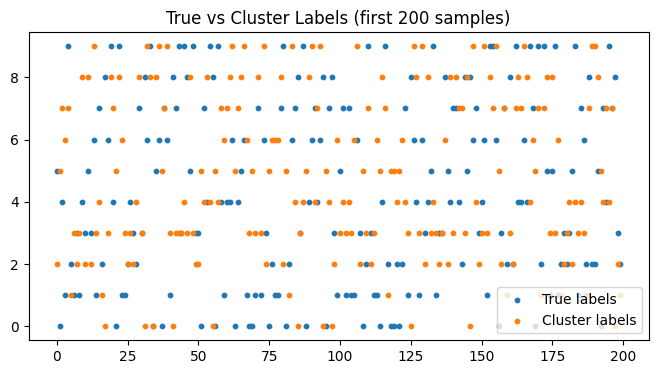


Done: MNIST clustering complete.


In [ ]:
k = 10
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_flat)

plt.figure(figsize=(8,4))
plt.scatter(range(200), y[:200], label="True labels", s=10)
plt.scatter(range(200), cluster_labels[:200], label="Cluster labels", s=10)
plt.legend()
plt.title("True vs Cluster Labels (first 200 samples)")
plt.show()

print("\nDone: MNIST clustering complete.")